**The purpose of this task is to analyse football data for the North west university res football teams and other prominent teams in the world.**

**this has been done to detremine what level should the res team of James Moroka be playing at to effectively win the residents tournement.**

our project will involve three phases.
1. Identifying the source of our professional data and once the data source has been identified we can then move to storing them in dataframes along with storing the data from the faculty.

2. Once the data is stored and succesfully placed in their respective dataframes we can move to analysis of the data using visulisation. this analysis will be followed with identifying methods to better help the team meet the performance requirments to play at a top level.

3. After analysis and recomandations have been done the project will be attached with a report showing findings and which can be presented to team officials.

#The data source that will be used is from statsbombpy

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install statsbombpy
from statsbombpy import sb

#loadoing the data that's wanted for the analysis
#Creating storage for the raw data
comps = sb.competitions()
matches = sb.matches(competition_id=43, season_id=106)


events = sb.events(match_id=matches.match_id.iloc[0])

passes = events[events.type == "Pass"]
completed_passes = passes[passes.pass_outcome.isna()]

shots = events[events.type == "Shot"]
shots_on_target = shots[shots.shot_outcome.isin(["Goal", "Saved"])]

all_stats = []

#looping throught the data source identify wanted fields
for match_id in matches.match_id:
    events = sb.events(match_id=match_id)

    # Filtering passes and shots for the current match
    passes_match = events[events.type == "Pass"]
    completed_passes_match = passes_match[passes_match.pass_outcome.isna()]

    shots_match = events[events.type == "Shot"]
    shots_on_target_match = shots_match[shots_match.shot_outcome.isin(["Goal", "Saved"])]
    goals_scored_match = shots_match[shots_match.shot_outcome == "Goal"]

    # Filtering duels, fouls, and offsides for the current match
    duels_match = events[events.type == "Duel"]
    fouls_match = events[events.type == "Foul Committed"]
    offsides_match = events[events.type == "Offside"]

    # finding the aggregate stats for each team in the current match
    team_stats_match = events.groupby("team").agg(
        total_passes=("type", lambda x: (x == "Pass").sum()),
        total_shots=("type", lambda x: (x == "Shot").sum())
    )

    # Adding completed passes, shots on target, goals scored, duels won, and fouls specifically
    for team in team_stats_match.index:
        num_completed_passes = completed_passes_match[completed_passes_match.team == team].shape[0]
        num_shots_on_target = shots_on_target_match[shots_on_target_match.team == team].shape[0]
        num_goals_scored = goals_scored_match[goals_scored_match.team == team].shape[0]

        # Duels won by the team
        duels_won = duels_match[(duels_match.team == team) & (duels_match.duel_outcome == 'Won')].shape[0]

        # Fouls committed by the team
        fouls_committed = fouls_match[fouls_match.team == team].shape[0]

        # Offsides by the team
        offsides_count = offsides_match[offsides_match.team == team].shape[0]

        team_stats_match.loc[team, 'completed_passes'] = num_completed_passes
        team_stats_match.loc[team, 'shots_on_target'] = num_shots_on_target
        team_stats_match.loc[team, 'goals_scored'] = num_goals_scored
        team_stats_match.loc[team, 'duels_won'] = duels_won
        team_stats_match.loc[team, 'fouls_committed'] = fouls_committed
        team_stats_match.loc[team, 'offsides'] = offsides_count
        team_stats_match.loc[team, 'match_id'] = match_id

    all_stats.append(team_stats_match)

# Concatenate all match stats into a single DataFrame
pros_df = pd.concat(all_stats).reset_index()

# Adding the competion name
pros_df = pros_df.merge(matches[['match_id', 'competition']], on='match_id', how='left')

pros_df = pros_df.rename(columns={'competition': 'competition_name'})

/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: 

Confriming if the data is from the 2022 World cup

In [51]:
selected_competition = comps[(comps['competition_id'] == 43) & (comps['season_id'] == 106)]
display(selected_competition)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845


In [52]:
#Dsiplaying all the collected stats from the external data source.
pros_df

,team,total_passes,total_shots,completed_passes,shots_on_target,goals_scored,duels_won,fouls_committed,offsides,match_id,competition_name
0,Serbia,521,12,407.0,4.0,2.0,3.0,21.0,0.0,3857256.0,International - FIFA World Cup
1,Switzerland,445,14,346.0,7.0,3.0,5.0,14.0,0.0,3857256.0,International - FIFA World Cup
2,Argentina,728,14,646.0,5.0,2.0,4.0,9.0,0.0,3869151.0,International - FIFA World Cup
3,Australia,478,5,384.0,1.0,0.0,1.0,18.0,0.0,3869151.0,International - FIFA World Cup
4,Australia,350,8,219.0,4.0,1.0,5.0,12.0,0.0,3857257.0,International - FIFA World Cup
...,...,...,...,...,...,...,...,...,...,...,...
123,Wales,351,7,274.0,1.0,0.0,2.0,19.0,0.0,3857261.0,International - FIFA World Cup
124,Japan,253,6,177.0,3.0,2.0,2.0,11.0,0.0,3857255.0,International - FIFA World Cup
125,Spain,1093,12,993.0,5.0,1.0,6.0,8.0,0.0,3857255.0,International - FIFA World Cup
126,Denmark,646,11,544.0,5.0,0.0,3.0,13.0,0.0,3857254.0,International - FIFA World Cup


In [54]:
#Seperate the games which have the highest goals vs the lowest scoring ones to diffrent dataframes.
total_goals_per_match = pros_df.groupby('match_id')['goals_scored'].sum().reset_index()
total_goals_per_match = total_goals_per_match.rename(columns={'goals_scored': 'total_goals'})

print("Total goals per match calculated:")
print(total_goals_per_match.head())

Total goals per match calculated:
    match_id  total_goals
0  3857254.0          0.0
1  3857255.0          3.0
2  3857256.0          5.0
3  3857257.0          1.0
4  3857258.0          2.0


In [55]:
#Finding the highest scoring gmaes and placing them seperatley from the lowest scoring games
highest_scoring_match_ids = total_goals_per_match.sort_values(by='total_goals', ascending=False).head(5)['match_id']
highest_scoring_matches = pros_df[pros_df['match_id'].isin(highest_scoring_match_ids)]

print("Top 5 highest scoring matches data:")
print(highest_scoring_matches.head(12))

Top 5 highest scoring matches data:
            team  total_passes  total_shots  completed_passes  \
12     Argentina           640           19             531.0   
13   Netherlands           691           12             572.0   
18     Argentina           693           24             560.0   
19        France           570           14             434.0   
44        Brazil           747           24             652.0   
45       Croatia           737           13             639.0   
88    Costa Rica           250            0             172.0   
89         Spain          1090           17            1009.0   
114      England           846           13             746.0   
115         Iran           247            8             163.0   

     shots_on_target  goals_scored  duels_won  fouls_committed  offsides  \
12               9.0           6.0        3.0             22.0       0.0   
13               7.0           5.0        4.0             37.0       0.0   
18              14.0

In [56]:
#Finding the lowest scoring games and seperating them from the highest scoring games
lowest_scoring_match_ids = total_goals_per_match.sort_values(by='total_goals', ascending=True).head(5)['match_id']
lowest_scoring_matches = pros_df[pros_df['match_id'].isin(lowest_scoring_match_ids)]

print("Top 5 lowest scoring matches data:")
print(lowest_scoring_matches.head(12))

Top 5 lowest scoring matches data:
              team  total_passes  total_shots  completed_passes  \
82         Belgium           630           16             543.0   
83         Croatia           609           11             514.0   
102        Croatia           686            5             577.0   
103        Morocco           384            8             301.0   
112        England           582            8             500.0   
113  United States           456           10             377.0   
118         Mexico           544           11             437.0   
119         Poland           362            6             259.0   
126        Denmark           646           11             544.0   
127        Tunisia           417           13             315.0   

     shots_on_target  goals_scored  duels_won  fouls_committed  offsides  \
82               3.0           0.0        0.0             10.0       0.0   
83               4.0           0.0        1.0             11.0       0.0   

From this separation  of games we witness that croatia even though having a game in the high scoring threshold also is the only team to apperar twice in the lowest scoring games list.

/tmp/ipykernel_659/3013368734.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=lowest_scoring_matches, x=stat, label='Lowest Scoring', fill=True, color='red', alpha=0.6)


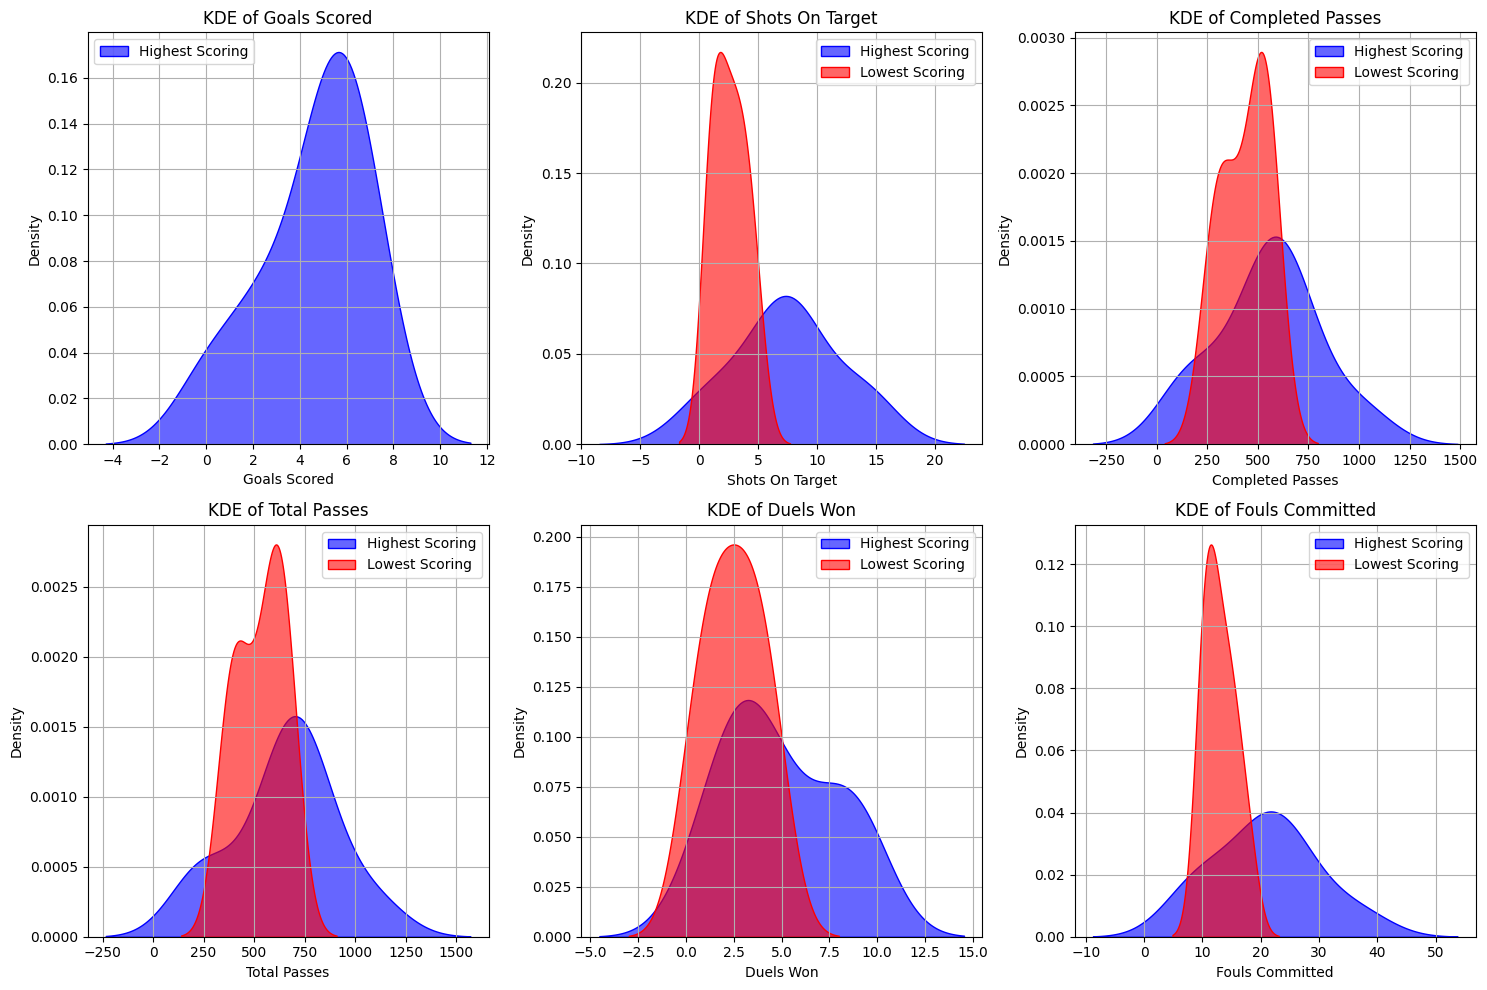

In [57]:
# Statistics to visualize
stats_to_visualize = ['goals_scored', 'shots_on_target', 'completed_passes', 'total_passes', 'duels_won', 'fouls_committed']

#PLotting the KDE to visualise the distribution of the diffrent metrics
plt.figure(figsize=(15, 10))
for i, stat in enumerate(stats_to_visualize):
    plt.subplot(2, 3, i + 1)
    sns.kdeplot(data=highest_scoring_matches, x=stat, label='Highest Scoring', fill=True, color='blue', alpha=0.6)
    sns.kdeplot(data=lowest_scoring_matches, x=stat, label='Lowest Scoring', fill=True, color='red', alpha=0.6)
    plt.title(f'KDE of {stat.replace("_", " ").title()}')
    plt.xlabel(stat.replace("_", " ").title())
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

From the KDE plot we see that the data for both high scoring and low scoring games are not in a sense disributed harshly therefore it is safe to use the mean beacause of a fairly normal distruibuted.

In [58]:
#Naming the fields which are required and printing the averages
avg_stats_highest_scoring = highest_scoring_matches[['goals_scored', 'shots_on_target', 'completed_passes', 'total_passes', 'duels_won', 'fouls_committed']].mean()
avg_stats_lowest_scoring = lowest_scoring_matches[['goals_scored', 'shots_on_target', 'completed_passes', 'total_passes', 'duels_won', 'fouls_committed']].mean()

print("Average stats for teams in highest scoring matches:")
print(avg_stats_highest_scoring)
print("\nAverage stats for teams in lowest scoring matches:")
print(avg_stats_lowest_scoring)

Average stats for teams in highest scoring matches:
goals_scored          4.6
shots_on_target       7.4
completed_passes    547.8
total_passes        651.1
duels_won             4.9
fouls_committed      20.7
dtype: float64

Average stats for teams in lowest scoring matches:
goals_scored          0.0
shots_on_target       2.6
completed_passes    436.7
total_passes        531.6
duels_won             2.5
fouls_committed      13.0
dtype: float64


#Visualizing the above metrics

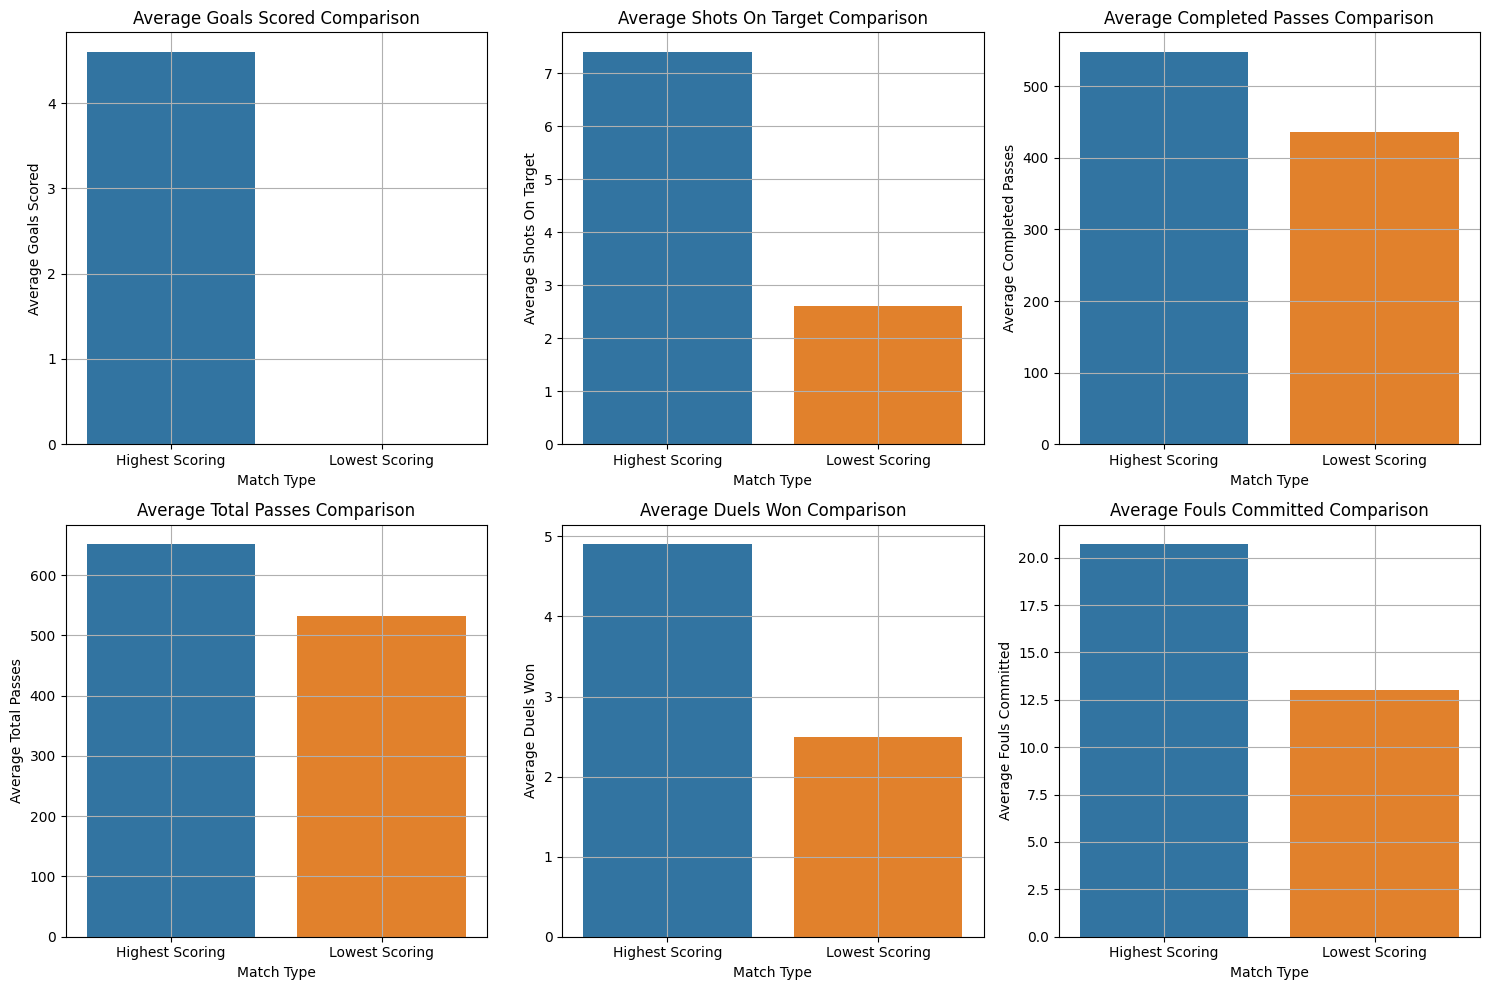

In [59]:

# Creating a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Highest Scoring': avg_stats_highest_scoring,
    'Lowest Scoring': avg_stats_lowest_scoring
}).T.reset_index()
comparison_df = comparison_df.rename(columns={'index': 'Match Type'})

# looping through all the fields and Plotting the averages to visualise for the Pros
stats_to_visualize = ['goals_scored', 'shots_on_target', 'completed_passes', 'total_passes', 'duels_won', 'fouls_committed']

plt.figure(figsize=(15, 10))
for i, stat in enumerate(stats_to_visualize):
    plt.subplot(2, 3, i + 1)
    sns.barplot(x='Match Type', y=stat, data=comparison_df, hue = 'Match Type' )
    plt.title(f'Average {stat.replace("_", " ").title()} Comparison')
    plt.xlabel('Match Type')
    plt.ylabel(f'Average {stat.replace("_", " ").title()}')
    plt.grid()

plt.tight_layout()
plt.show()

In [65]:
#Finding the average stats for all the metrics regardless of match types
common_metrics = ['goals_scored', 'shots_on_target', 'completed_passes', 'total_shots', 'duels_won', 'fouls_committed']
avg_pros_stats = pros_df[common_metrics].mean()

print("Average statistics for professional data:")
print(avg_pros_stats)

Average statistics for professional data:
goals_scored          1.523438
shots_on_target       4.226562
completed_passes    440.203125
total_shots          11.671875
duels_won             3.812500
fouls_committed      13.867188
dtype: float64


Lets start our analysis with a heat map to find linearality between the variables. Once this has been our exploraitary analysis will have direction to finding more out from our dataset

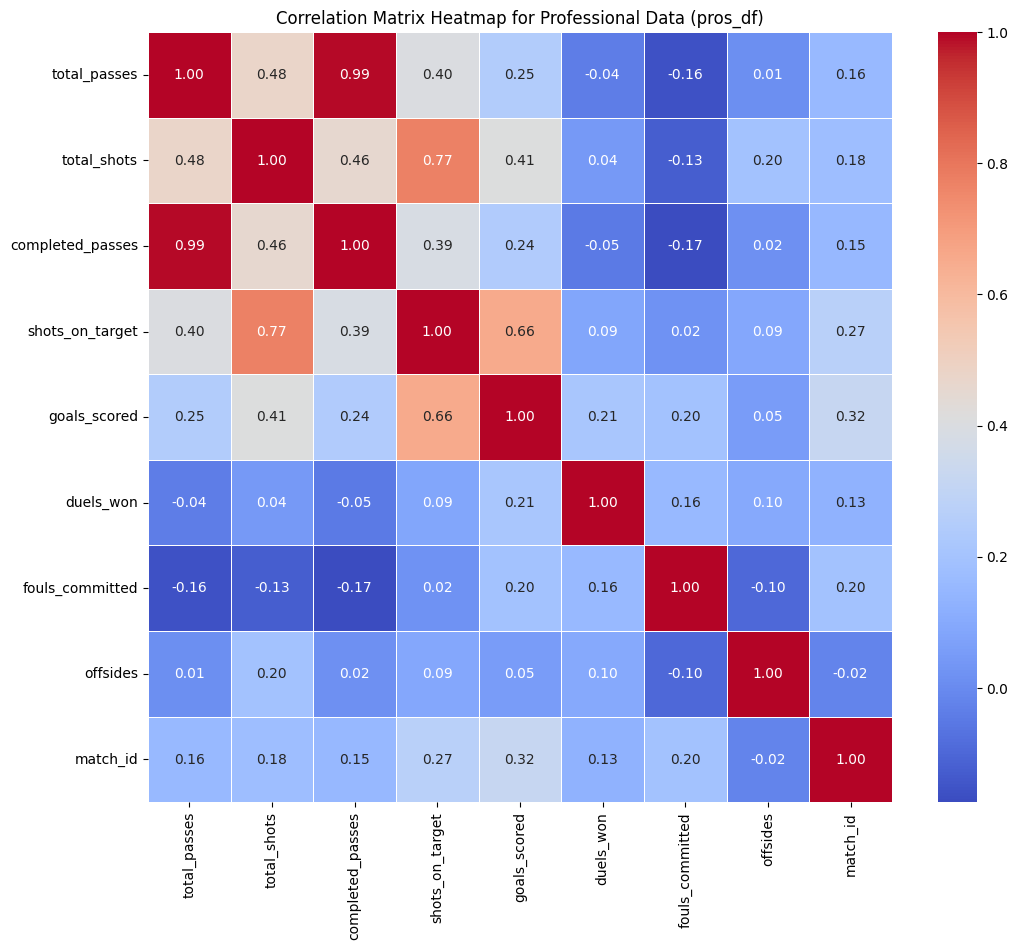

In [67]:
#Creating a correlation matrix and finding relations between variables

# Calculating the correlation matrix for pros_df
# Selecting only numeric columns to avoid errors with non-numeric data
numeric_cols_pros = pros_df.select_dtypes(include=np.number)
corr_matrix_pros = numeric_cols_pros.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(data=corr_matrix_pros, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap for Professional Data (pros_df)')
plt.show()

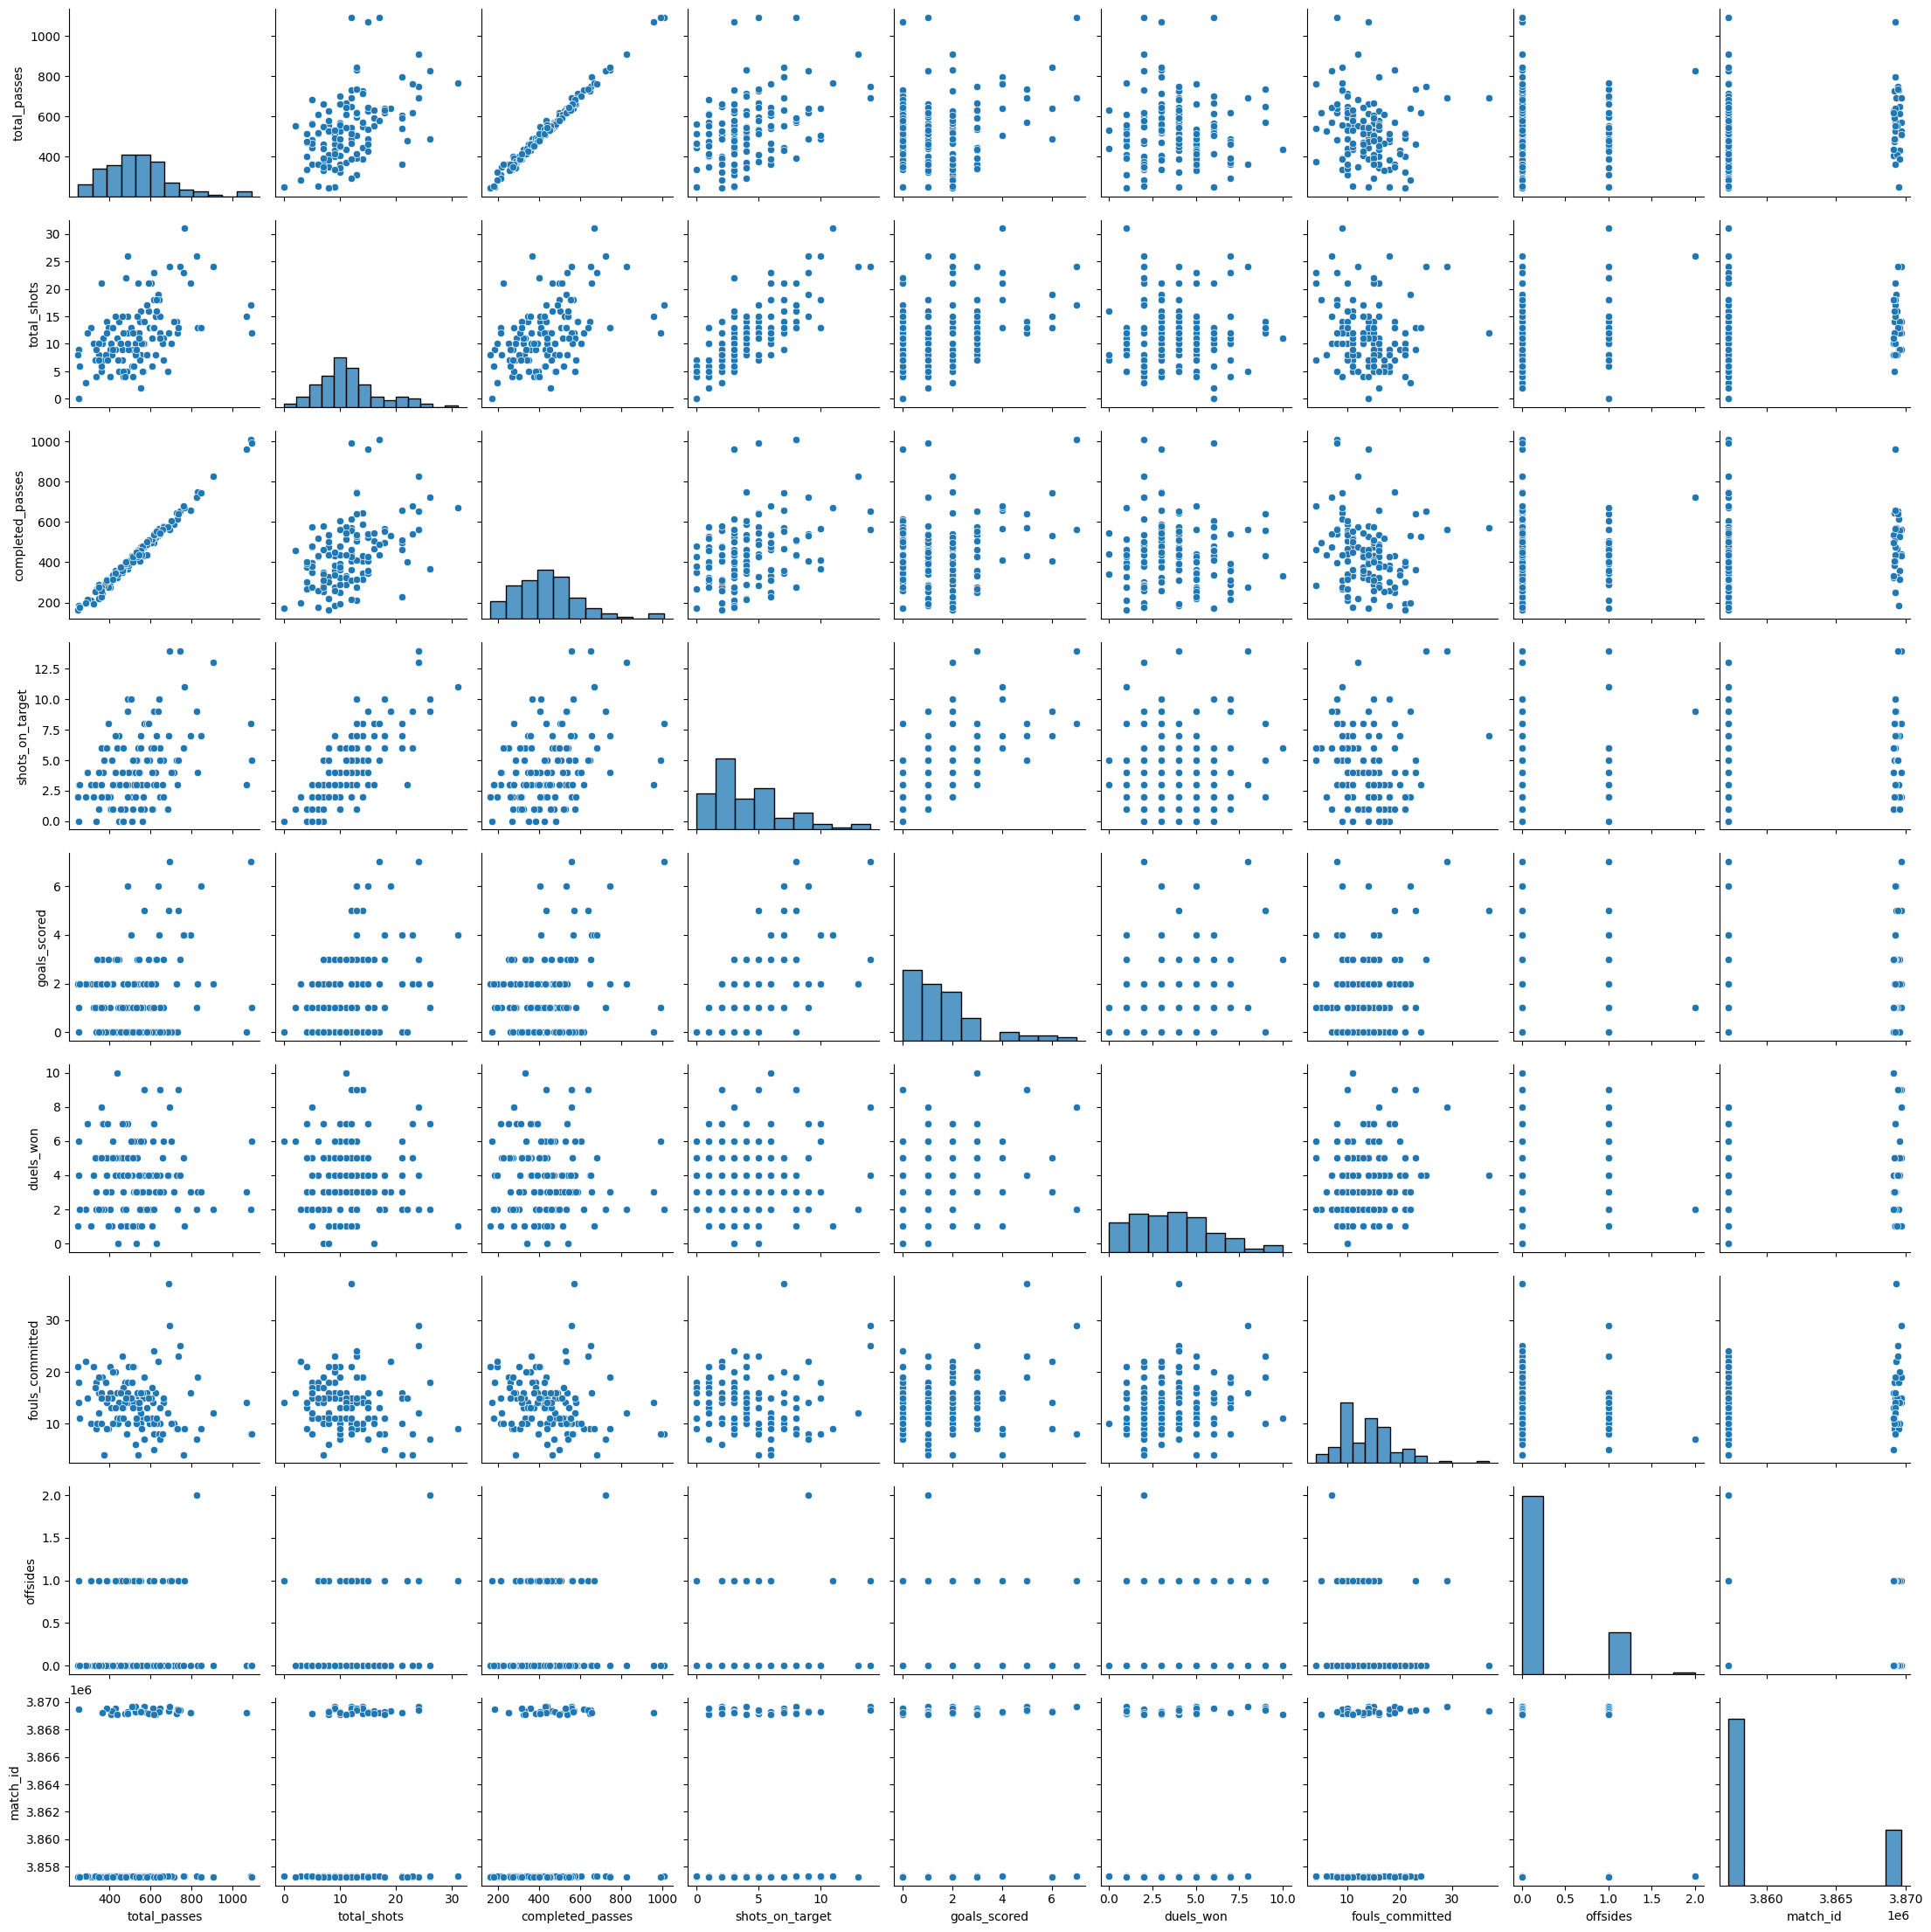

In [68]:
#Plotting a pairplot to find the distribution of the diffrent variables.
sns.pairplot(pros_df)

So with our dataset and using the correlation matrix diagran we see that shots on target and goals scored have a very strong relationship so that will be the starting point of our analysis.

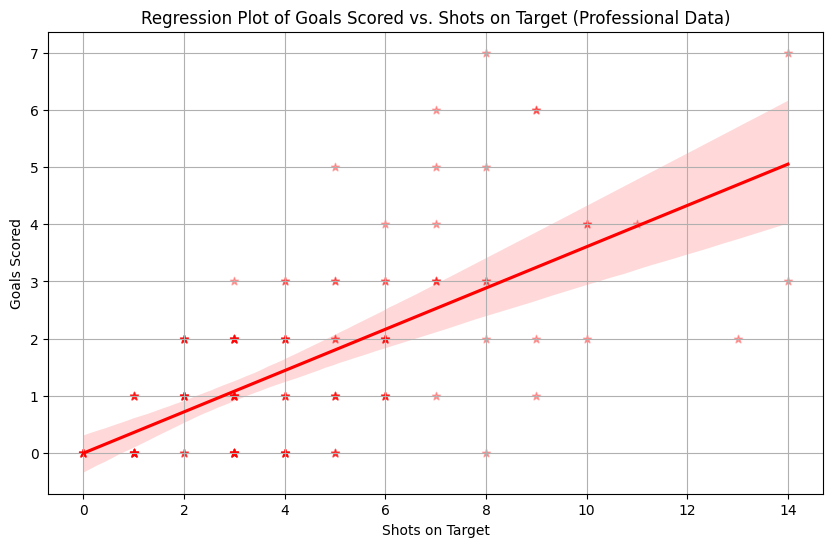

In [69]:
plt.figure(figsize=(10, 6))
sns.regplot(x='shots_on_target', y='goals_scored', data=pros_df, scatter_kws={'alpha':0.3}, color = 'r', marker = '*')
plt.title('Regression Plot of Goals Scored vs. Shots on Target (Professional Data)')
plt.xlabel('Shots on Target')
plt.ylabel('Goals Scored')
plt.grid(True)
plt.show()

The linearality of the data is not strong where we have a positive strong relatiowsnship but because football is so complex we can therefore assume that non of the variables will have such a strong relationship.

In [70]:
#Looking at the teams with the most shots on target
team_shots_on_target = pros_df.groupby('team')['shots_on_target'].sum().reset_index()
print("Total shots on target per team in World cup data:")
print(team_shots_on_target.head(10))

Total shots on target per team in World cup data:
         team  shots_on_target
0   Argentina             56.0
1   Australia              8.0
2     Belgium             10.0
3      Brazil             46.0
4    Cameroon             16.0
5      Canada              5.0
6  Costa Rica              6.0
7     Croatia             33.0
8     Denmark             11.0
9     Ecuador             11.0


In [71]:
#Sorting the teams with the most shots on target to find the top 10
top_10_teams_shots_on_target = team_shots_on_target.sort_values(by='shots_on_target', ascending=False).head(10)
print("Top 10 teams by shots on target:")
print(top_10_teams_shots_on_target)

Top 10 teams by shots on target:
           team  shots_on_target
0     Argentina             56.0
3        Brazil             46.0
11       France             38.0
7       Croatia             33.0
10      England             28.0
20     Portugal             26.0
12      Germany             24.0
18  Netherlands             21.0
17      Morocco             20.0
25  South Korea             18.0


the teams with the most shots on target were found because an assumption has been made that those are the teams that may have had the most goals scored as well.

Now that we have found the teams with the most shots on target lets find out how many goals they have scored once this is done we can search the pro's data frame again to find the teams that scored the most goals through the whole tournemnt.

In [72]:
#counting th goals scored by the teams with the most shots on target.
top_10_teams = top_10_teams_shots_on_target['team'].tolist()
filtered_pros_df = pros_df[pros_df['team'].isin(top_10_teams)]
total_goals = filtered_pros_df.groupby('team')['goals_scored'].sum().reset_index()
total_goals = total_goals.sort_values(by='goals_scored', ascending=False)

print("Total goals scored for top 10 teams by shots on target:")
print(total_goals)

Total goals scored for top 10 teams by shots on target:
          team  goals_scored
0    Argentina          23.0
4       France          18.0
2      Croatia          15.0
3      England          13.0
7  Netherlands          13.0
8     Portugal          12.0
1       Brazil          10.0
6      Morocco           9.0
5      Germany           6.0
9  South Korea           5.0


In [73]:
# Merging the shots on target data with the total goals scored for the top 10 teams to plot on the barplott
merged_top_teams_stats = pd.merge(
    top_10_teams_shots_on_target,
    total_goals,
    on='team',
    how='left'
).fillna(0.0)

print("Merged DataFrame of top teams by shots on target and goals scored:")
display(merged_top_teams_stats.head())


Merged DataFrame of top teams by shots on target and goals scored:


,team,shots_on_target,goals_scored
0,Argentina,56.0,23.0
1,Brazil,46.0,10.0
2,France,38.0,18.0
3,Croatia,33.0,15.0
4,England,28.0,13.0


In [74]:
# Formatting the dataframe to plot the barplot.
merged_top_teams_stats_melted = merged_top_teams_stats.melt(
    id_vars=['team'],
    value_vars=['goals_scored', 'shots_on_target'],
    var_name='Metric',
    value_name='Value'
)

print("Melted DataFrame for plotting:")
display(merged_top_teams_stats_melted.head())


Melted DataFrame for plotting:


,team,Metric,Value
0,Argentina,goals_scored,23.0
1,Brazil,goals_scored,10.0
2,France,goals_scored,18.0
3,Croatia,goals_scored,15.0
4,England,goals_scored,13.0


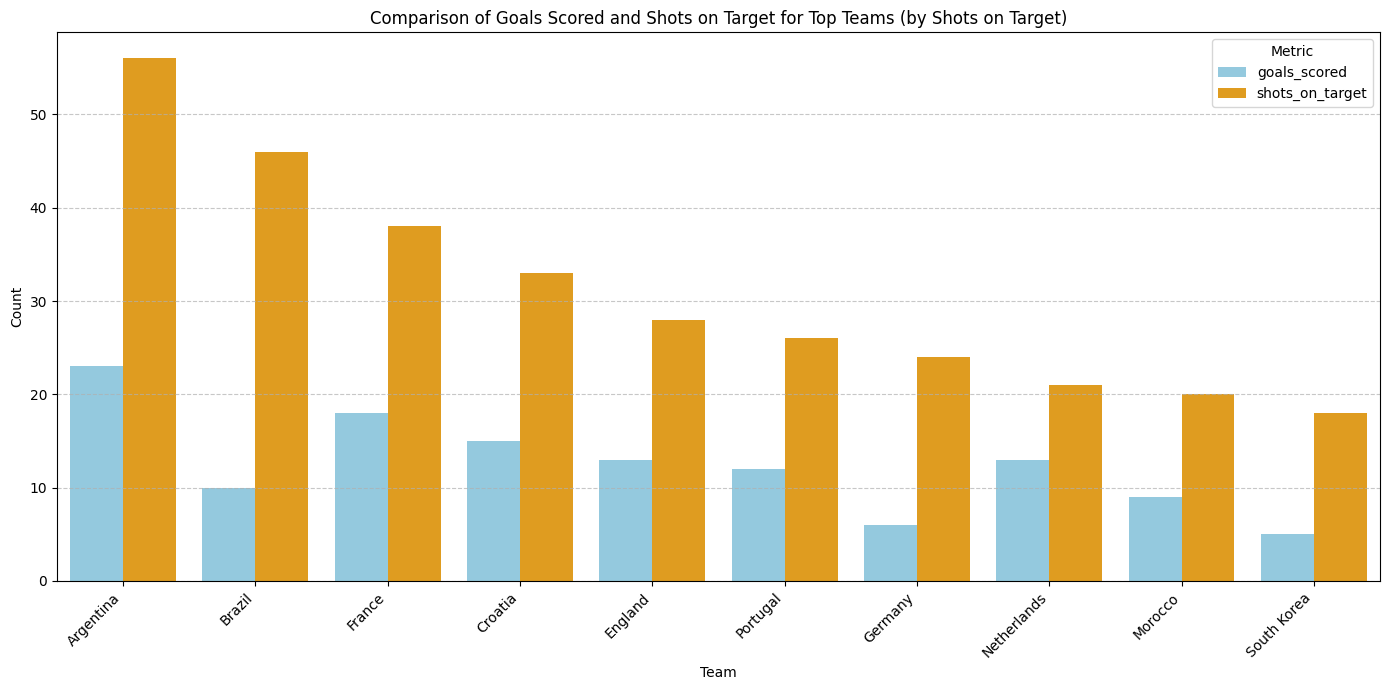

In [75]:
#Plotting the barplot so shots on target and goals scored by the team are persented.
plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='Value', hue='Metric', data=merged_top_teams_stats_melted, palette={'goals_scored': 'skyblue', 'shots_on_target': 'orange'})
plt.title('Comparison of Goals Scored and Shots on Target for Top Teams (by Shots on Target)')
plt.xlabel('Team')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Now that we have the teams which had the most shots on target lets create a seprate data frame where we find the teams that have scored the most goals through out the tournement.

The hoping of doing this is to prove that once the shots on target increase your chances of scoring goals will increase as well resulting in more goals scored. So the hypothesis is the more shots on target the more goals that will have been scored.

In [76]:
#Finding the teams that scored the most goals in the world cup
total_goals_per_team = pros_df.groupby('team')['goals_scored'].sum().reset_index()
top_10_teams_by_goals = total_goals_per_team.sort_values(by='goals_scored', ascending=False).head(10)

print("Top 10 teams by total goals scored:")
print(top_10_teams_by_goals)


Top 10 teams by total goals scored:
           team  goals_scored
0     Argentina          23.0
11       France          18.0
7       Croatia          15.0
10      England          13.0
18  Netherlands          13.0
20     Portugal          12.0
3        Brazil          10.0
17      Morocco           9.0
26        Spain           9.0
15        Japan           6.0


So from this piece of code we see that 80% of the teams that made the top 10 shots on target list also made the top 10 total goals list excluding spain and japan

Theres a good indication that the teams that can get infront of goal the most and take their shots are most likely going to score the most goals in a tournment.

In [77]:
#Finding the teams that avergaed the most goals in the world cup.
total_goals_per_team = pros_df.groupby('team')['goals_scored'].mean().reset_index()
top_10_teams_by_goals = total_goals_per_team.sort_values(by='goals_scored', ascending=False).head(10)

top_10_teams_by_goals['goals_scored'] = top_10_teams_by_goals['goals_scored'].round(1)

print("Average goals scored per game:")
print(top_10_teams_by_goals)


Average goals scored per game:
           team  goals_scored
0     Argentina           3.3
10      England           2.6
18  Netherlands           2.6
11       France           2.6
20     Portugal           2.4
26        Spain           2.2
7       Croatia           2.1
3        Brazil           2.0
12      Germany           2.0
24       Serbia           1.7


Again we see that 80% of the teams that made the top 10 shots on target list averaged the most goals per game as well with the leader of shots on target leading total goals and average goals scored in a game.

The next relationship i want to explore is Duels won and goals scored even though our correlation metrix shows a low relationship i believe it is a strong indication of winning and scoring goals as a team that can win the ball creates oppurtuinites to score the goals.

In [78]:
#Looking for the teams with the most duels won.
team_duels_won = pros_df.groupby('team')['duels_won'].sum().reset_index()
print("Total duels won per team in World cup data:")
print(team_duels_won.head(10))

Total duels won per team in World cup data:
         team  duels_won
0   Argentina       27.0
1   Australia       18.0
2     Belgium        9.0
3      Brazil       22.0
4    Cameroon        6.0
5      Canada        8.0
6  Costa Rica       11.0
7     Croatia       37.0
8     Denmark       12.0
9     Ecuador       18.0


In [79]:
#Sorting the teams with the most duels won to find the top 10
top_10_teams_duels_won = team_duels_won.sort_values(by='duels_won', ascending=False).head(10)
print("Top 10 teams by duels Won:")
print(top_10_teams_duels_won)

Top 10 teams by duels Won:
           team  duels_won
7       Croatia       37.0
11       France       34.0
17      Morocco       30.0
0     Argentina       27.0
18  Netherlands       27.0
3        Brazil       22.0
9       Ecuador       18.0
1     Australia       18.0
20     Portugal       18.0
10      England       17.0


In [80]:
#counting th goals scored by the teams with the most duels won
top_10_teams_by_duels = top_10_teams_duels_won['team'].tolist()
filtered_pros_df_duels = pros_df[pros_df['team'].isin(top_10_teams_by_duels)]
total_duels = filtered_pros_df_duels.groupby('team')['goals_scored'].sum().reset_index()
total_duels = total_duels.sort_values(by='goals_scored', ascending=False)

print("Total goals scored for top 10 teams by duels won:")
print(total_duels)

Total goals scored for top 10 teams by duels won:
          team  goals_scored
0    Argentina          23.0
6       France          18.0
3      Croatia          15.0
8  Netherlands          13.0
5      England          13.0
9     Portugal          12.0
2       Brazil          10.0
7      Morocco           9.0
4      Ecuador           4.0
1    Australia           3.0


In [81]:
# Merging the duels won data with the total goals scored for the top 10 teams to plot on the barplott
merged_top_teams_stats_duels = pd.merge(
    top_10_teams_duels_won,
    total_duels,
    on='team',
    how='left'
).fillna(0.0)

print("Merged DataFrame of top teams by duels won and goals scored:")
display(merged_top_teams_stats_duels.head())


Merged DataFrame of top teams by duels won and goals scored:


,team,duels_won,goals_scored
0,Croatia,37.0,15.0
1,France,34.0,18.0
2,Morocco,30.0,9.0
3,Argentina,27.0,23.0
4,Netherlands,27.0,13.0


In [82]:
# Formatting the dataframe to plot the barplot.
merged_top_teams_stats_melted_duels = merged_top_teams_stats_duels.melt(
    id_vars=['team'],
    value_vars=['goals_scored', 'duels_won'],
    var_name='Metric',
    value_name='Value'
)

print("Melted DataFrame for plotting:")
display(merged_top_teams_stats_melted_duels.head())

Melted DataFrame for plotting:


,team,Metric,Value
0,Croatia,goals_scored,15.0
1,France,goals_scored,18.0
2,Morocco,goals_scored,9.0
3,Argentina,goals_scored,23.0
4,Netherlands,goals_scored,13.0


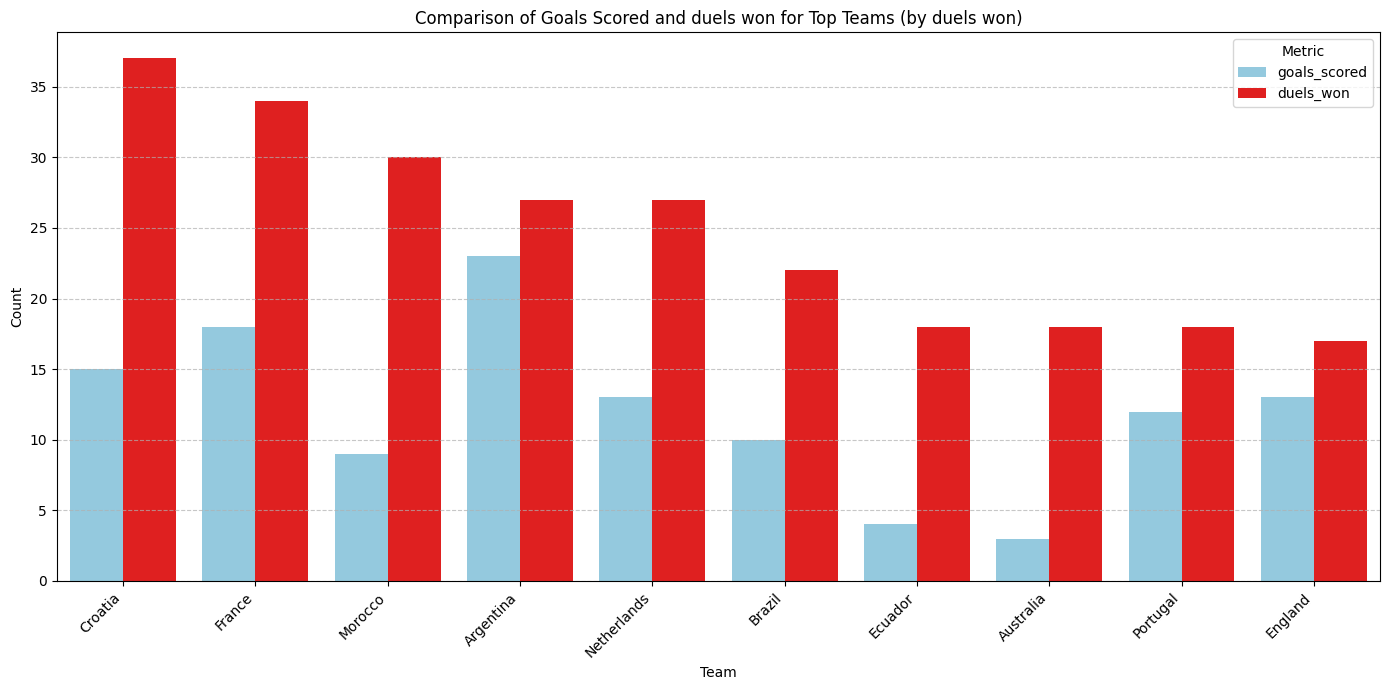

In [83]:
#Plotting the barplot so shots on target and goals scored by the team are persented.
plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='Value', hue='Metric', data=merged_top_teams_stats_melted_duels, palette={'goals_scored': 'skyblue', 'duels_won': 'red'})
plt.title('Comparison of Goals Scored and duels won for Top Teams (by duels won)')
plt.xlabel('Team')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [84]:
#Finding the teams that avergaed the most duels won in the world cup.
total_duels_won_per_team = pros_df.groupby('team')['duels_won'].mean().reset_index()
top_10_teams_by_duels = total_duels_won_per_team.sort_values(by='duels_won', ascending=False).head(10)

top_10_teams_by_duels['duels_won'] = top_10_teams_by_duels['duels_won'].round(1)

print("Average duels won per game:")
print(top_10_teams_by_duels)


Average duels won per game:
           team  duels_won
9       Ecuador        6.0
18  Netherlands        5.4
28      Tunisia        5.3
7       Croatia        5.3
13        Ghana        5.0
11       France        4.9
1     Australia        4.5
3        Brazil        4.4
16       Mexico        4.3
24       Serbia        4.3


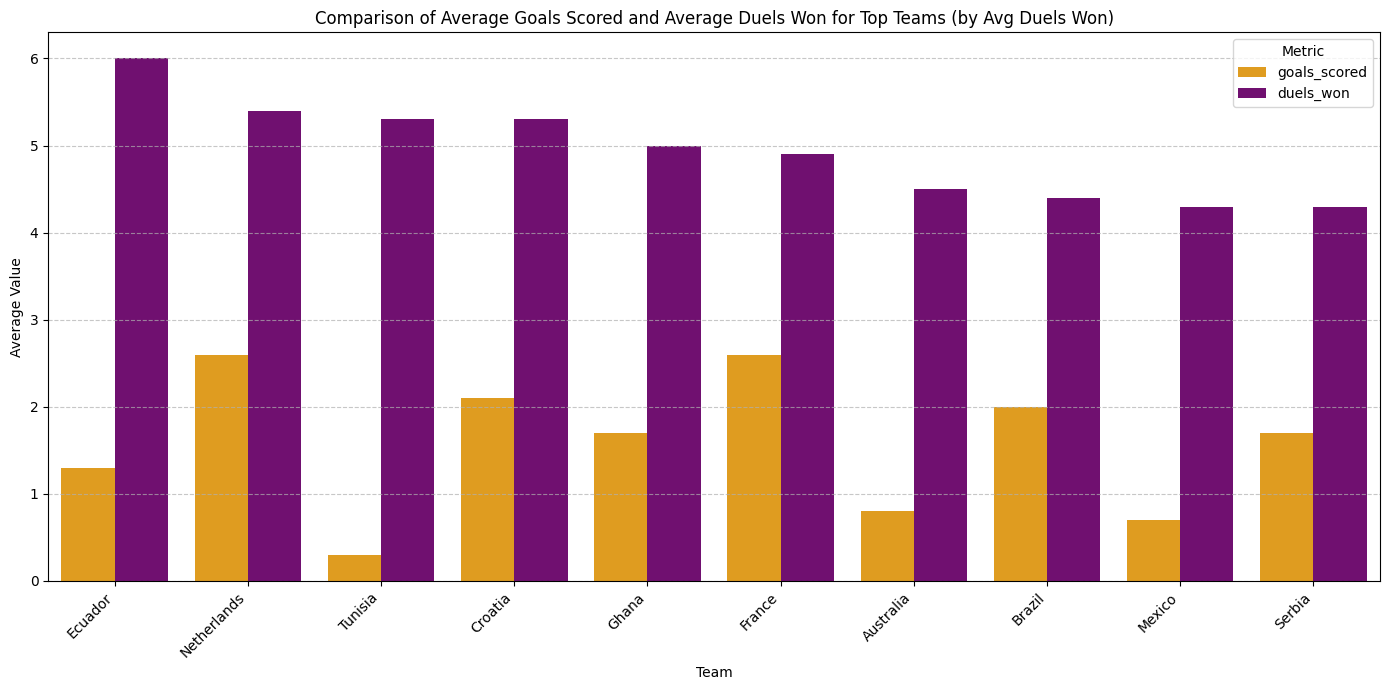

In [85]:
# Identify top 10 teams by average duels won
#block example
top_10_teams_by_avg_duels = total_duels_won_per_team.sort_values(by='duels_won', ascending=False).head(10)

# Get the list of teams from this top 10
teams_for_comparison = top_10_teams_by_avg_duels['team'].tolist()

# Filter average goals scored for these specific teams
avg_goals_for_these_teams = total_goals_per_team[total_goals_per_team['team'].isin(teams_for_comparison)]

# Merge the average duels won and average goals scored
merged_avg_stats = pd.merge(
    top_10_teams_by_avg_duels,
    avg_goals_for_these_teams,
    on='team',
    how='left'
).fillna(0.0)

# Round the values to one decimal place as requested
merged_avg_stats['duels_won'] = merged_avg_stats['duels_won'].round(1)
merged_avg_stats['goals_scored'] = merged_avg_stats['goals_scored'].round(1)

# Melt the DataFrame for plotting
merged_avg_stats_melted = merged_avg_stats.melt(
    id_vars=['team'],
    value_vars=['goals_scored', 'duels_won'],
    var_name='Metric',
    value_name='Value'
)

# Plotting the barplot
plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='Value', hue='Metric', data=merged_avg_stats_melted, palette={'goals_scored': 'Orange', 'duels_won': 'purple'})
plt.title('Comparison of Average Goals Scored and Average Duels Won for Top Teams (by Avg Duels Won)')
plt.xlabel('Team')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

There are only few teams who passed the average for goals scored and duels won which are:

* The Netherlands
* Croatia
* Ghana
* France
* Brazil
* Serbia

these teams performed well when it came to goal scoring and ball retention.  

In [86]:
#Sorting the teams with the most completed passes to find the top 10
team_compPasses = pros_df.groupby('team')['completed_passes'].sum().reset_index()
top_10_teams_compPasses = team_compPasses.sort_values(by='completed_passes', ascending=False).head(10)
print("Top 10 teams by completed passes:")
print(top_10_teams_compPasses)

Top 10 teams by completed passes:
             team  completed_passes
0       Argentina            3939.0
7         Croatia            3796.0
26          Spain            3540.0
11         France            3291.0
10        England            2800.0
3          Brazil            2776.0
20       Portugal            2655.0
18    Netherlands            2501.0
17        Morocco            2292.0
29  United States            1822.0


In [87]:
# Getting the list of teams the from top_10_teams_compPasses
top_teams_list = top_10_teams_compPasses['team'].tolist()

# Finding the average completed passes per game for each team
avg_comp_passes_per_team = pros_df.groupby('team')['completed_passes'].mean().reset_index()

# Filtering the data to only show the teams in our top ten
average_passes_for_top_teams = avg_comp_passes_per_team[avg_comp_passes_per_team['team'].isin(top_teams_list)]

print("Average completed passes per game for teams in top_10_teams_compPasses:")
print(average_passes_for_top_teams.round(1))

Average completed passes per game for teams in top_10_teams_compPasses:
             team  completed_passes
0       Argentina             562.7
3          Brazil             555.2
7         Croatia             542.3
10        England             560.0
11         France             470.1
17        Morocco             327.4
18    Netherlands             500.2
20       Portugal             531.0
26          Spain             885.0
29  United States             455.5


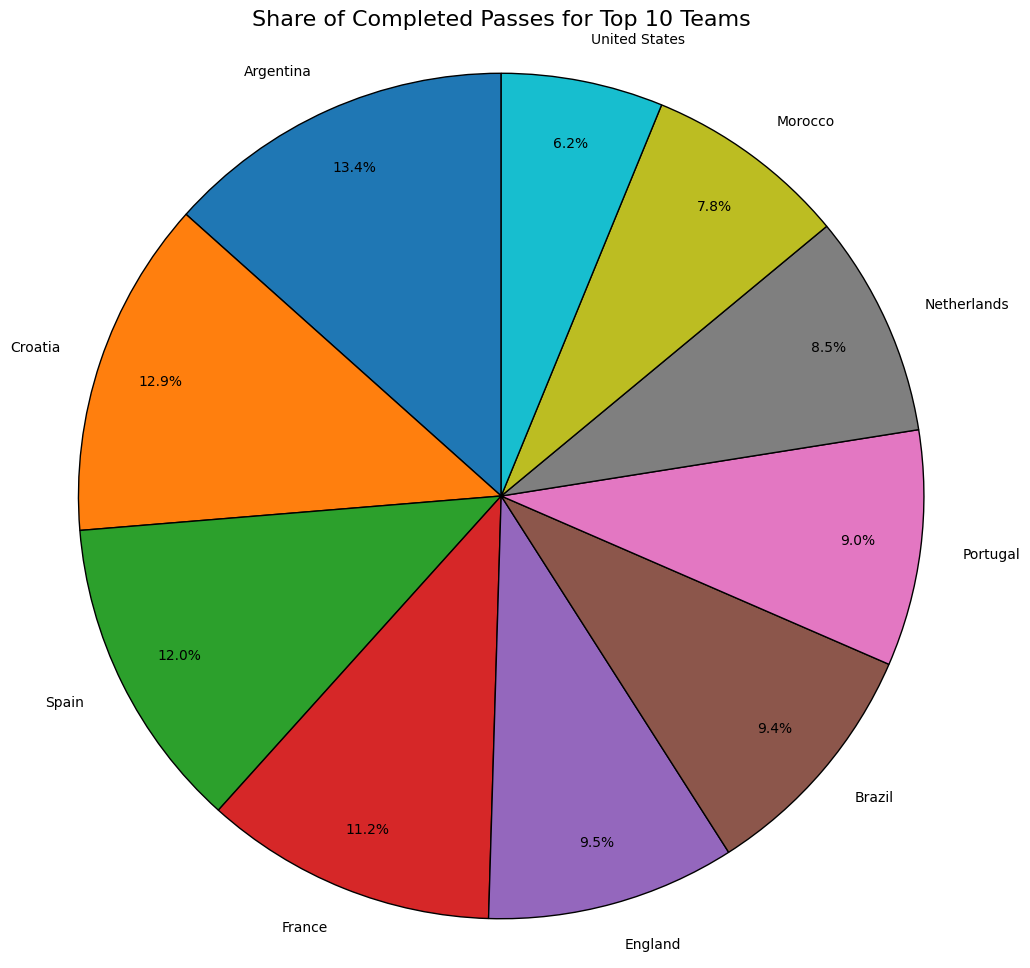

In [88]:
#Plotting a Pie chart to visualise the share space of the diffrent teams

# Preparing the data for the pie chart
labels = top_10_teams_compPasses['team']
sizes = top_10_teams_compPasses['completed_passes']

#Plotting the pieplot to show the share of coimpleted passes by the top 10 teams
plt.figure(figsize=(12, 12))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'black'})
plt.axis('equal')
plt.title('Share of Completed Passes for Top 10 Teams', fontsize=16)
plt.show()

Looking at the Fouls committed.

In [89]:
#Finding the top 10 teams for fouls committed.
team_fouls_committed = pros_df.groupby('team')['fouls_committed'].sum().reset_index()

top_10_teams_fouls_committed = team_fouls_committed.sort_values(by='fouls_committed', ascending=False).head(10)

print("Top 10 teams by fouls committed:")
print(top_10_teams_fouls_committed)

Top 10 teams by fouls committed:
            team  fouls_committed
17       Morocco            115.0
0      Argentina            114.0
7        Croatia            101.0
18   Netherlands             99.0
11        France             75.0
3         Brazil             66.0
15         Japan             63.0
27   Switzerland             61.0
1      Australia             60.0
22  Saudi Arabia             59.0


In [90]:
#Creating a separte data frame for the top 10 teams by fouls committed
top_10_fouls_teams = top_10_teams_fouls_committed['team'].tolist()
filtered_pros_df_fouls = pros_df[pros_df['team'].isin(top_10_fouls_teams)]

print("Filtered DataFrame for top 10 teams by fouls committed:")
print(filtered_pros_df_fouls.head())

Filtered DataFrame for top 10 teams by fouls committed:
          team  total_passes  total_shots  completed_passes  shots_on_target  \
1  Switzerland           445           14             346.0              7.0   
2    Argentina           728           14             646.0              5.0   
3    Australia           478            5             384.0              1.0   
4    Australia           350            8             219.0              4.0   
6       Brazil           618           23             539.0              9.0   

   goals_scored  duels_won  fouls_committed  offsides   match_id  \
1           3.0        5.0             14.0       0.0  3857256.0   
2           2.0        4.0              9.0       0.0  3869151.0   
3           0.0        1.0             18.0       0.0  3869151.0   
4           1.0        5.0             12.0       0.0  3857257.0   
6           2.0        7.0              8.0       0.0  3857258.0   

                 competition_name  
1  International -

In [91]:
#Finding the total goals scored for each team in the top 10
total_goals_for_fouls_teams = filtered_pros_df_fouls.groupby('team')['goals_scored'].sum().reset_index()

print("Total goals scored for top 10 teams by fouls committed:")
print(total_goals_for_fouls_teams)

Total goals scored for top 10 teams by fouls committed:
           team  goals_scored
0     Argentina          23.0
1     Australia           3.0
2        Brazil          10.0
3       Croatia          15.0
4        France          18.0
5         Japan           6.0
6       Morocco           9.0
7   Netherlands          13.0
8  Saudi Arabia           3.0
9   Switzerland           5.0


In [92]:
#Merging the two fields for better visulisation
merged_top_teams_stats_fouls = pd.merge(
    top_10_teams_fouls_committed,
    total_goals_for_fouls_teams,
    on='team',
    how='left'
).fillna(0.0)

print("Merged DataFrame of top teams by fouls committed and goals scored:")
print(merged_top_teams_stats_fouls.head())

Merged DataFrame of top teams by fouls committed and goals scored:
          team  fouls_committed  goals_scored
0      Morocco            115.0           9.0
1    Argentina            114.0          23.0
2      Croatia            101.0          15.0
3  Netherlands             99.0          13.0
4       France             75.0          18.0


In [93]:
merged_top_teams_stats_melted_fouls = merged_top_teams_stats_fouls.melt(
    id_vars=['team'],
    value_vars=['goals_scored', 'fouls_committed'],
    var_name='Metric',
    value_name='Value'
)

print("Melted DataFrame for plotting:")
print(merged_top_teams_stats_melted_fouls.head())

Melted DataFrame for plotting:
          team        Metric  Value
0      Morocco  goals_scored    9.0
1    Argentina  goals_scored   23.0
2      Croatia  goals_scored   15.0
3  Netherlands  goals_scored   13.0
4       France  goals_scored   18.0


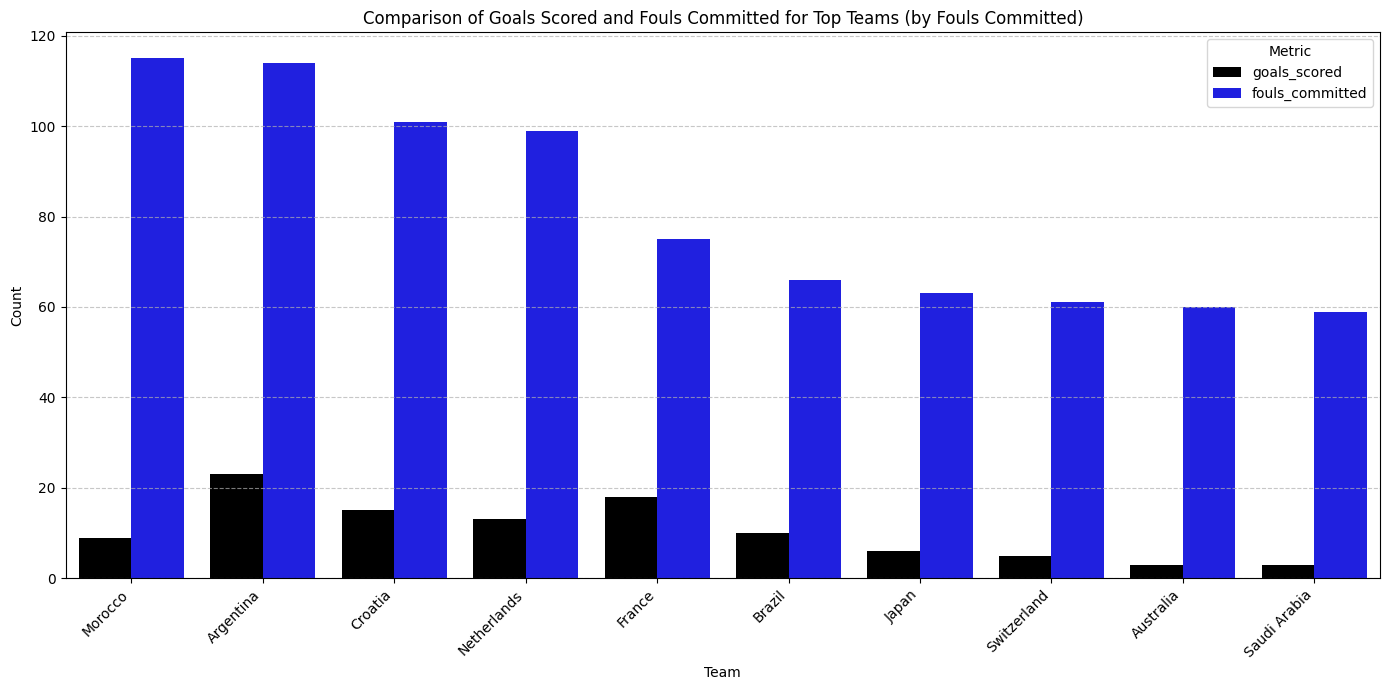

In [94]:
#Plotting the total goals scored and the fouls committed by each team
plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='Value', hue='Metric', data=merged_top_teams_stats_melted_fouls, palette={'goals_scored': 'black', 'fouls_committed': 'blue'})
plt.title('Comparison of Goals Scored and Fouls Committed for Top Teams (by Fouls Committed)')
plt.xlabel('Team')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [95]:
#Findin the average fouls committed by each team per game.
avg_team_fouls_committed = pros_df.groupby('team')['fouls_committed'].mean().reset_index()

top_10_teams_avg_fouls_committed = avg_team_fouls_committed.sort_values(by='fouls_committed', ascending=False).head(10)

print("Top 10 teams by average fouls committed:")
print(top_10_teams_avg_fouls_committed)

Top 10 teams by average fouls committed:
            team  fouls_committed
18   Netherlands        19.800000
22  Saudi Arabia        19.666667
16        Mexico        17.666667
14          Iran        17.333333
13         Ghana        17.000000
9        Ecuador        16.666667
17       Morocco        16.428571
0      Argentina        16.285714
24        Serbia        16.000000
15         Japan        15.750000


In [96]:
#Filterig data using a dataframe
top_10_avg_fouls_teams = top_10_teams_avg_fouls_committed['team'].tolist()
filtered_pros_df_avg_fouls = pros_df[pros_df['team'].isin(top_10_avg_fouls_teams)]

print("Filtered DataFrame for top 10 teams by average fouls committed:")
print(filtered_pros_df_avg_fouls.head())

Filtered DataFrame for top 10 teams by average fouls committed:
         team  total_passes  total_shots  completed_passes  shots_on_target  \
0      Serbia           521           12             407.0              4.0   
2   Argentina           728           14             646.0              5.0   
7      Serbia           446            5             351.0              0.0   
10    Ecuador           465            9             362.0              4.0   
12  Argentina           640           19             531.0              9.0   

    goals_scored  duels_won  fouls_committed  offsides   match_id  \
0            2.0        3.0             21.0       0.0  3857256.0   
2            2.0        4.0              9.0       0.0  3869151.0   
7            0.0        5.0             11.0       0.0  3857258.0   
10           1.0        5.0             23.0       0.0  3857267.0   
12           6.0        3.0             22.0       0.0  3869321.0   

                  competition_name  
0   Inter

In [97]:
#Printing the goals scored by teams in the top 10 list for fouls committed.
avg_goals_for_avg_fouls_teams = filtered_pros_df_avg_fouls.groupby('team')['goals_scored'].mean().reset_index()

print("Average goals scored for top 10 teams by average fouls committed:")
print(avg_goals_for_avg_fouls_teams)

Average goals scored for top 10 teams by average fouls committed:
           team  goals_scored
0     Argentina      3.285714
1       Ecuador      1.333333
2         Ghana      1.666667
3          Iran      1.333333
4         Japan      1.500000
5        Mexico      0.666667
6       Morocco      1.285714
7   Netherlands      2.600000
8  Saudi Arabia      1.000000
9        Serbia      1.666667


In [98]:
merged_avg_stats_fouls = pd.merge(
    top_10_teams_avg_fouls_committed,
    avg_goals_for_avg_fouls_teams,
    on='team',
    how='left'
).fillna(0.0)

print("Merged DataFrame of top teams by average fouls committed and average goals scored:")
print(merged_avg_stats_fouls.head())

Merged DataFrame of top teams by average fouls committed and average goals scored:
           team  fouls_committed  goals_scored
0   Netherlands        19.800000      2.600000
1  Saudi Arabia        19.666667      1.000000
2        Mexico        17.666667      0.666667
3          Iran        17.333333      1.333333
4         Ghana        17.000000      1.666667


In [99]:
merged_avg_stats_melted_fouls = merged_avg_stats_fouls.melt(
    id_vars=['team'],
    value_vars=['goals_scored', 'fouls_committed'],
    var_name='Metric',
    value_name='Value'
)

print("Melted DataFrame for plotting:")
print(merged_avg_stats_melted_fouls.head())

Melted DataFrame for plotting:
           team        Metric     Value
0   Netherlands  goals_scored  2.600000
1  Saudi Arabia  goals_scored  1.000000
2        Mexico  goals_scored  0.666667
3          Iran  goals_scored  1.333333
4         Ghana  goals_scored  1.666667


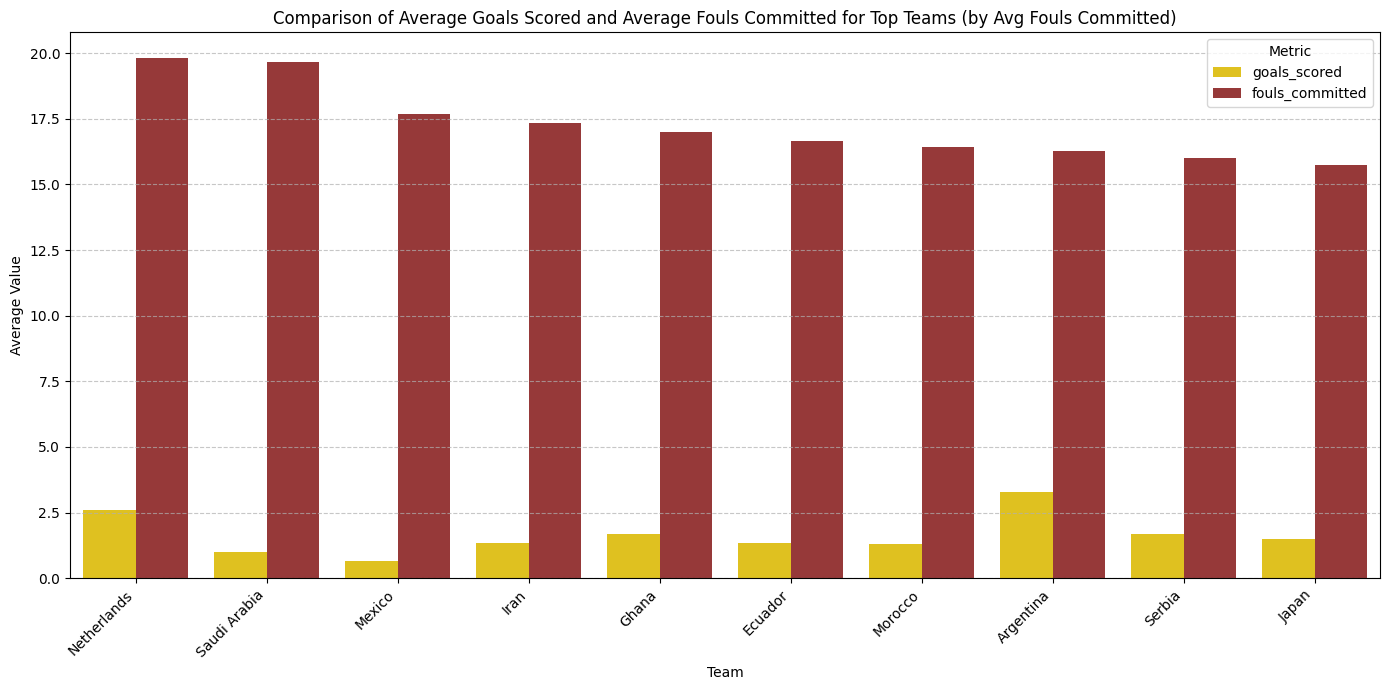

In [109]:
#PLotting the average fouls and goals scored
plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='Value', hue='Metric', data=merged_avg_stats_melted_fouls, palette={'goals_scored': 'gold', 'fouls_committed': 'brown'})
plt.title('Comparison of Average Goals Scored and Average Fouls Committed for Top Teams (by Avg Fouls Committed)')
plt.xlabel('Team')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Looking at offsides committed

In [101]:
#Finding the teams with in the top 10 for offsides
team_offsides = pros_df.groupby('team')['offsides'].sum().reset_index()

top_10_teams_offsides = team_offsides.sort_values(by='offsides', ascending=False).head(10)

print("Top 10 teams by offsides:")
print(top_10_teams_offsides)

Top 10 teams by offsides:
           team  offsides
12      Germany       3.0
23      Senegal       3.0
11       France       2.0
9       Ecuador       2.0
17      Morocco       2.0
25  South Korea       2.0
7       Croatia       1.0
0     Argentina       1.0
6    Costa Rica       1.0
24       Serbia       1.0


In [102]:
top_10_offsides_teams = top_10_teams_offsides['team'].tolist()

print("List of top 10 teams by offsides:")
print(top_10_offsides_teams)

List of top 10 teams by offsides:
['Germany', 'Senegal', 'France', 'Ecuador', 'Morocco', 'South Korea', 'Croatia', 'Argentina', 'Costa Rica', 'Serbia']


In [103]:
#Creating a data frame for better analysis
filtered_pros_df_offsides = pros_df[pros_df['team'].isin(top_10_offsides_teams)]

print("Filtered DataFrame for top 10 teams by offsides:")
print(filtered_pros_df_offsides.head())

Filtered DataFrame for top 10 teams by offsides:
         team  total_passes  total_shots  completed_passes  shots_on_target  \
0      Serbia           521           12             407.0              4.0   
2   Argentina           728           14             646.0              5.0   
7      Serbia           446            5             351.0              0.0   
10    Ecuador           465            9             362.0              4.0   
11    Senegal           311           13             213.0              3.0   

    goals_scored  duels_won  fouls_committed  offsides   match_id  \
0            2.0        3.0             21.0       0.0  3857256.0   
2            2.0        4.0              9.0       0.0  3869151.0   
7            0.0        5.0             11.0       0.0  3857258.0   
10           1.0        5.0             23.0       0.0  3857267.0   
11           2.0        1.0             10.0       1.0  3857267.0   

                  competition_name  
0   International - FIFA

In [104]:
#Showing the top 10 team by offsides goals scored
total_goals_for_offsides_teams = filtered_pros_df_offsides.groupby('team')['goals_scored'].sum().reset_index()

print("Total goals scored for top 10 teams by offsides:")
print(total_goals_for_offsides_teams)

Total goals scored for top 10 teams by offsides:
          team  goals_scored
0    Argentina          23.0
1   Costa Rica           2.0
2      Croatia          15.0
3      Ecuador           4.0
4       France          18.0
5      Germany           6.0
6      Morocco           9.0
7      Senegal           5.0
8       Serbia           5.0
9  South Korea           5.0


In [105]:
merged_top_teams_stats_offsides = pd.merge(
    top_10_teams_offsides,
    total_goals_for_offsides_teams,
    on='team',
    how='left'
).fillna(0.0)

print("Merged DataFrame of top teams by offsides and goals scored:")
print(merged_top_teams_stats_offsides.head())

Merged DataFrame of top teams by offsides and goals scored:
      team  offsides  goals_scored
0  Germany       3.0           6.0
1  Senegal       3.0           5.0
2   France       2.0          18.0
3  Ecuador       2.0           4.0
4  Morocco       2.0           9.0


In [106]:
#Merging the two metrics together
merged_top_teams_stats_melted_offsides = merged_top_teams_stats_offsides.melt(
    id_vars=['team'],
    value_vars=['goals_scored', 'offsides'],
    var_name='Metric',
    value_name='Value'
)

print("Melted DataFrame for plotting:")
print(merged_top_teams_stats_melted_offsides.head())

Melted DataFrame for plotting:
      team        Metric  Value
0  Germany  goals_scored    6.0
1  Senegal  goals_scored    5.0
2   France  goals_scored   18.0
3  Ecuador  goals_scored    4.0
4  Morocco  goals_scored    9.0


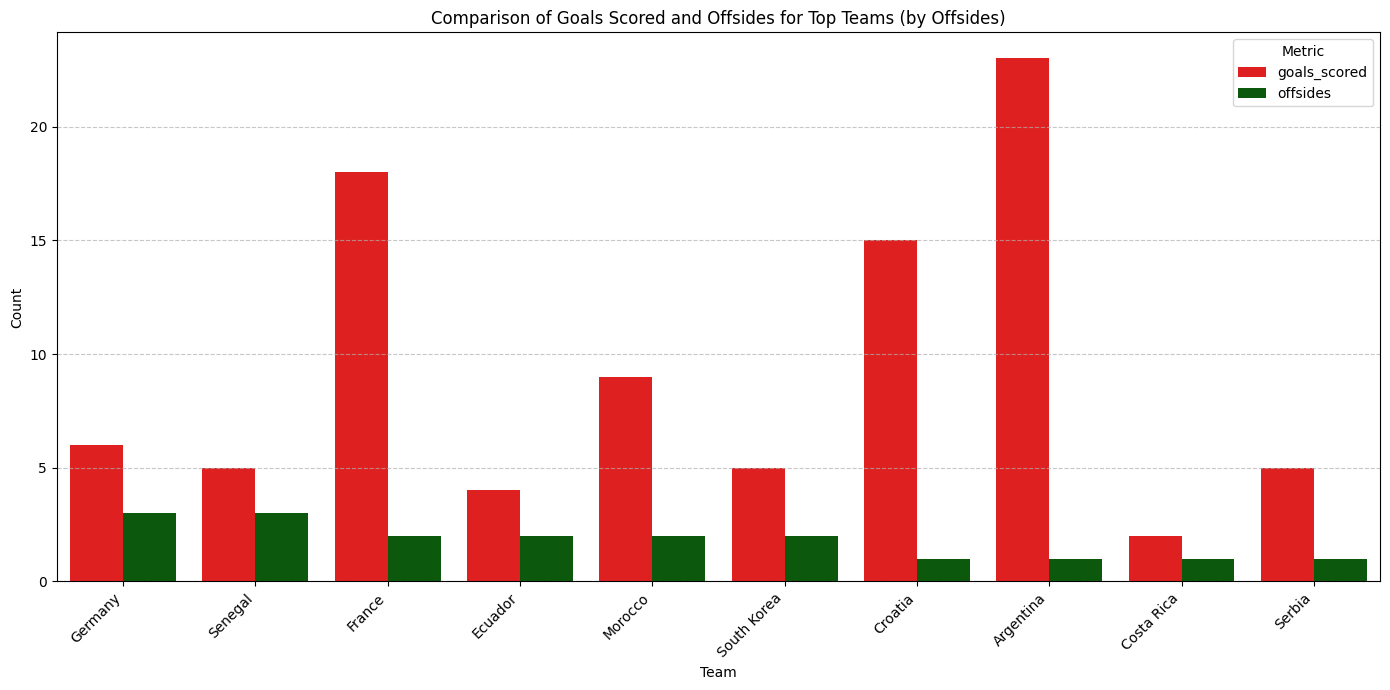

In [111]:
#Plotting the total offsides and total goals scored.
plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='Value', hue='Metric', data=merged_top_teams_stats_melted_offsides, palette={'goals_scored': 'red', 'offsides': 'darkgreen'})
plt.title('Comparison of Goals Scored and Offsides for Top Teams (by Offsides)')
plt.xlabel('Team')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

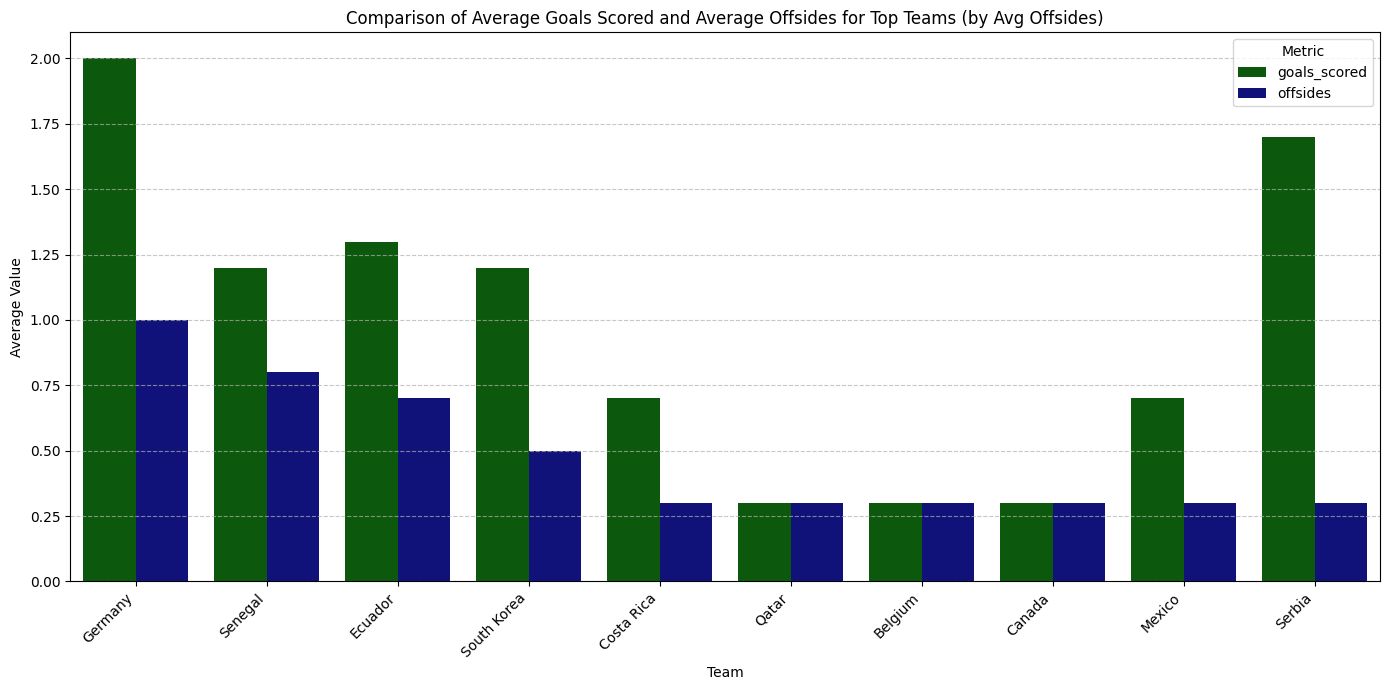

In [110]:
#PLotting the average fouls commiitted and the average goals scored.

# Calculate average offsides per team
avg_team_offsides = pros_df.groupby('team')['offsides'].mean().reset_index()

# Identify top 10 teams by average offsides
top_10_teams_avg_offsides = avg_team_offsides.sort_values(by='offsides', ascending=False).head(10)

# Get the list of teams from this top 10
top_10_avg_offsides_teams_list = top_10_teams_avg_offsides['team'].tolist()

# Filter average goals scored for these specific teams (using total_goals_per_team which stores average goals)
avg_goals_for_avg_offsides_teams = total_goals_per_team[total_goals_per_team['team'].isin(top_10_avg_offsides_teams_list)]

# Merge the average offsides and average goals scored
merged_avg_stats_offsides = pd.merge(
    top_10_teams_avg_offsides,
    avg_goals_for_avg_offsides_teams,
    on='team',
    how='left'
).fillna(0.0)

# Round the values to one decimal place for better presentation
merged_avg_stats_offsides['offsides'] = merged_avg_stats_offsides['offsides'].round(1)
merged_avg_stats_offsides['goals_scored'] = merged_avg_stats_offsides['goals_scored'].round(1)

# Melt the DataFrame for plotting
merged_avg_stats_melted_offsides = merged_avg_stats_offsides.melt(
    id_vars=['team'],
    value_vars=['goals_scored', 'offsides'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(14, 7))
sns.barplot(x='team', y='Value', hue='Metric', data=merged_avg_stats_melted_offsides, palette={'goals_scored': 'Darkgreen', 'offsides': 'Darkblue'})
plt.title('Comparison of Average Goals Scored and Average Offsides for Top Teams (by Avg Offsides)')
plt.xlabel('Team')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()